In [51]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error

Размер изображения: (1080, 1920) | тип данных: uint8


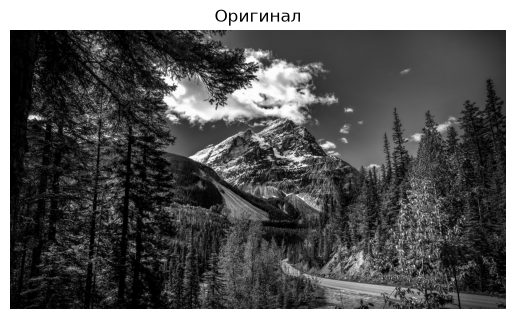

In [52]:
# 1) Загрузка фото
image = cv2.imread("sar_1_gray.jpg")
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
print("Размер изображения:", image_gray.shape, "| тип данных:", image_gray.dtype)

plt.imshow(image_gray, cmap="gray")
plt.title("Оригинал")
plt.axis("off")
plt.show()

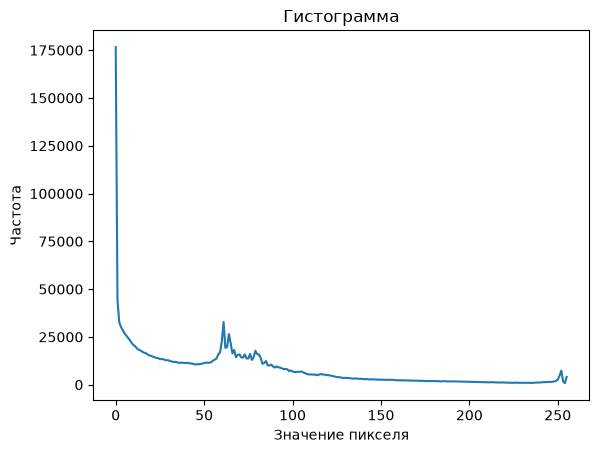

In [53]:
# 2) Гистограмма
hist = cv2.calcHist([image_gray], [0], None, [256], (0, 256), accumulate=False)

plt.plot(hist)
plt.title("Гистограмма")
plt.xlabel("Значение пикселя")
plt.ylabel("Частота")
plt.show()

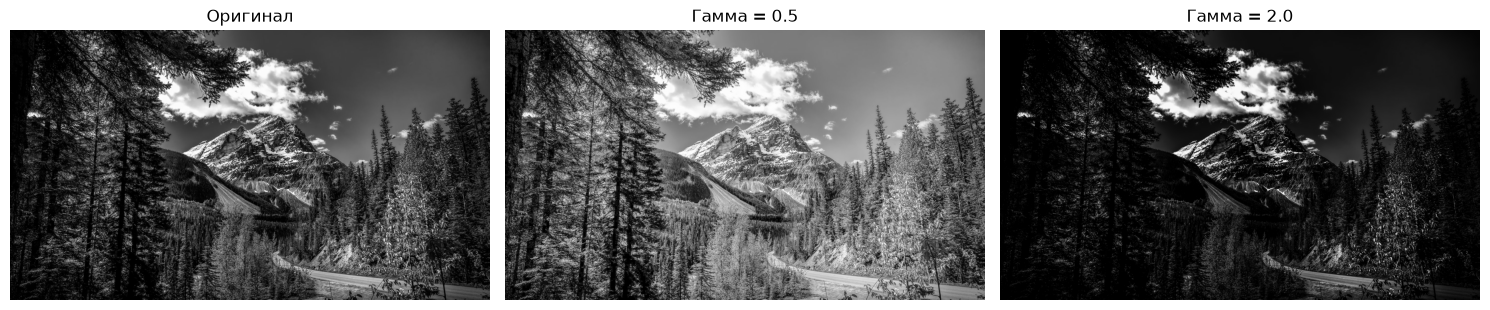

Средняя яркость пикселей:
   оригинал         : 62.11
   гамма = 0.5      : 108.24
   гамма = 2.0      : 27.83


In [54]:
# 3) Алгоритм гамма-коррекции
gamma_low  = 0.5
gamma_high = 2.0

normalized = image_gray.astype(np.float64) / 255.0

corrected_low  = np.power(normalized, gamma_low)  * 255.0
corrected_low  = np.clip(corrected_low, 0, 255).astype(np.uint8)

corrected_high = np.power(normalized, gamma_high) * 255.0
corrected_high = np.clip(corrected_high, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(image_gray,      cmap="gray"); axes[0].set_title("Оригинал")
axes[1].imshow(corrected_low,   cmap="gray"); axes[1].set_title(f"Гамма = {gamma_low}")
axes[2].imshow(corrected_high,  cmap="gray"); axes[2].set_title(f"Гамма = {gamma_high}")
for ax in axes: ax.axis("off")
plt.tight_layout()
plt.show()

print("Средняя яркость пикселей:")
print(f"   оригинал         : {image_gray.mean():.2f}")
print(f"   гамма = {gamma_low}      : {corrected_low.mean():.2f}")
print(f"   гамма = {gamma_high}      : {corrected_high.mean():.2f}")

In [55]:
# 4) Сравнение оригинала и гамма-коррекции: MSE, SSIM
print("Сравнение гамма-коррекции с оригиналом:")

for gamma, corrected in [(gamma_low, corrected_low), (gamma_high, corrected_high)]:
    ssim_val = structural_similarity(image_gray, corrected)
    mse_val  = mean_squared_error(image_gray, corrected)
    print(f"   гамма = {gamma}:  SSIM = {ssim_val:.4f},  MSE = {mse_val:.2f}")

Сравнение гамма-коррекции с оригиналом:
   гамма = 0.5:  SSIM = 0.6955,  MSE = 2545.33
   гамма = 2.0:  SSIM = 0.4840,  MSE = 1669.68


Статистическая цветокоррекция (по статистике eq_gray):
   eq_gray:   ср. яркость = 117.52, контраст = 78.62
   оригинал:  ср. яркость = 62.11, контраст = 57.73
   результат: ср. яркость = 112.52, контраст = 67.35


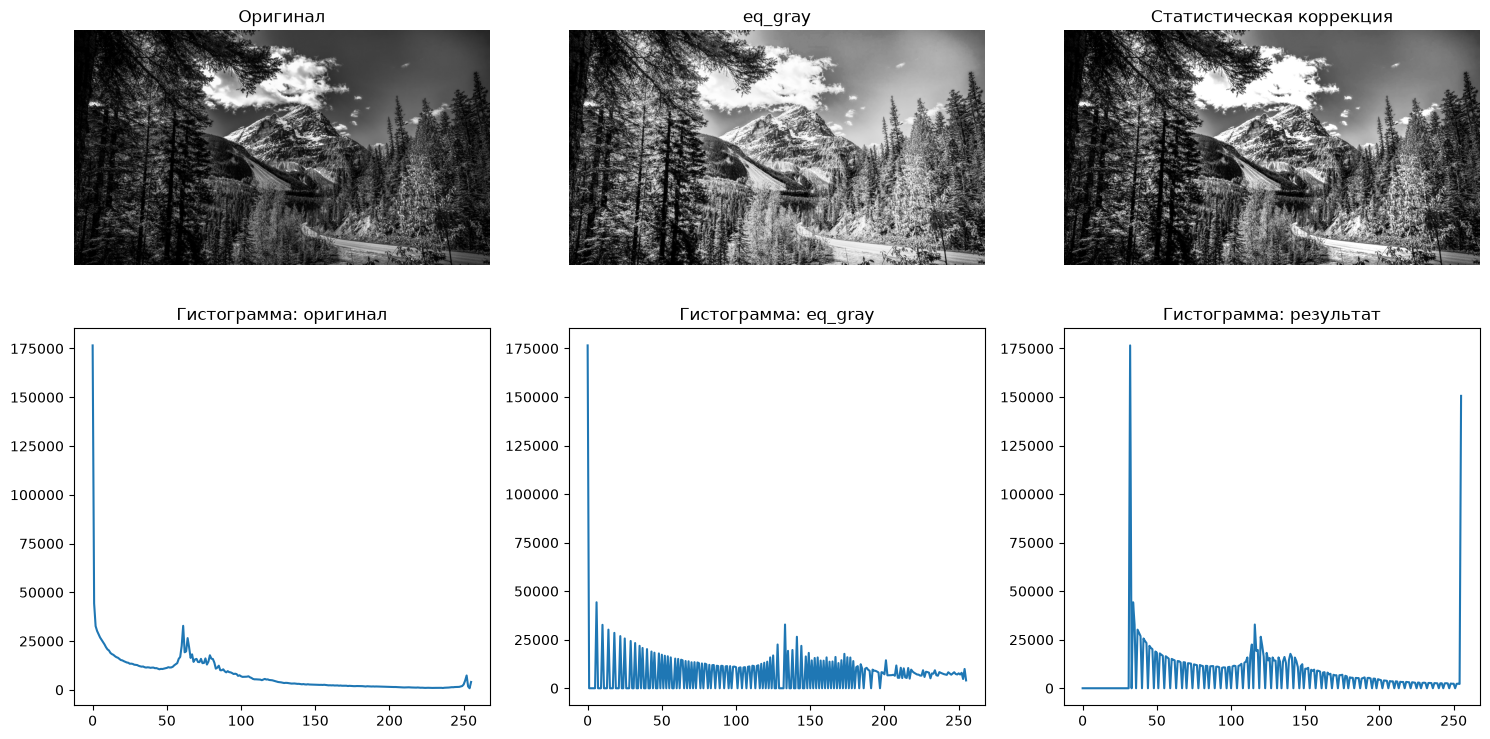

In [56]:
# 5) Статистическая цветокоррекция на основе статистики eq_gray
hist_cum = hist.cumsum()
cdf_min  = hist_cum[hist_cum > 0].min()

lut = np.round((hist_cum - cdf_min) / (image_gray.size - cdf_min) * 255)
lut = np.clip(lut, 0, 255).astype(np.uint8)
eq_gray = lut[image_gray]

mean, std = eq_gray.mean(), eq_gray.std()

source = image_gray.astype(np.float64)
stat_corrected = (source - source.mean()) * (std / source.std()) + mean
stat_corrected = np.clip(stat_corrected, 0, 255).astype(np.uint8)

print("Статистическая цветокоррекция (по статистике eq_gray):")
print(f"   eq_gray:   ср. яркость = {mean:.2f}, контраст = {std:.2f}")
print(f"   оригинал:  ср. яркость = {image_gray.mean():.2f}, контраст = {image_gray.std():.2f}")
print(f"   результат: ср. яркость = {stat_corrected.mean():.2f}, контраст = {stat_corrected.std():.2f}")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].imshow(image_gray,     cmap="gray"); axes[0, 0].set_title("Оригинал")
axes[0, 1].imshow(eq_gray,        cmap="gray"); axes[0, 1].set_title("eq_gray")
axes[0, 2].imshow(stat_corrected, cmap="gray"); axes[0, 2].set_title("Статистическая коррекция")

axes[1, 0].plot(cv2.calcHist([image_gray],     [0], None, [256], (0, 256)))
axes[1, 0].set_title("Гистограмма: оригинал")
axes[1, 1].plot(cv2.calcHist([eq_gray],        [0], None, [256], (0, 256)))
axes[1, 1].set_title("Гистограмма: eq_gray")
axes[1, 2].plot(cv2.calcHist([stat_corrected], [0], None, [256], (0, 256)))
axes[1, 2].set_title("Гистограмма: результат")

for ax in axes[0]: ax.axis("off")
plt.tight_layout()
plt.show()

In [57]:
# 6) Пороговая фильтрация с разными параметрами
methods = {
    "BINARY":     cv2.THRESH_BINARY,
    "BINARY_INV": cv2.THRESH_BINARY_INV,
    "TRUNC":      cv2.THRESH_TRUNC,
    "TOZERO":     cv2.THRESH_TOZERO,
    "OTSU":       cv2.THRESH_BINARY + cv2.THRESH_OTSU,
}

BINARY при разных порогах:
   порог = 60.0 -> белых:  943436, чёрных: 1130164
   порог = 127.0 -> белых:  253068, чёрных: 1820532
   порог = 200.0 -> белых:   81701, чёрных: 1991899


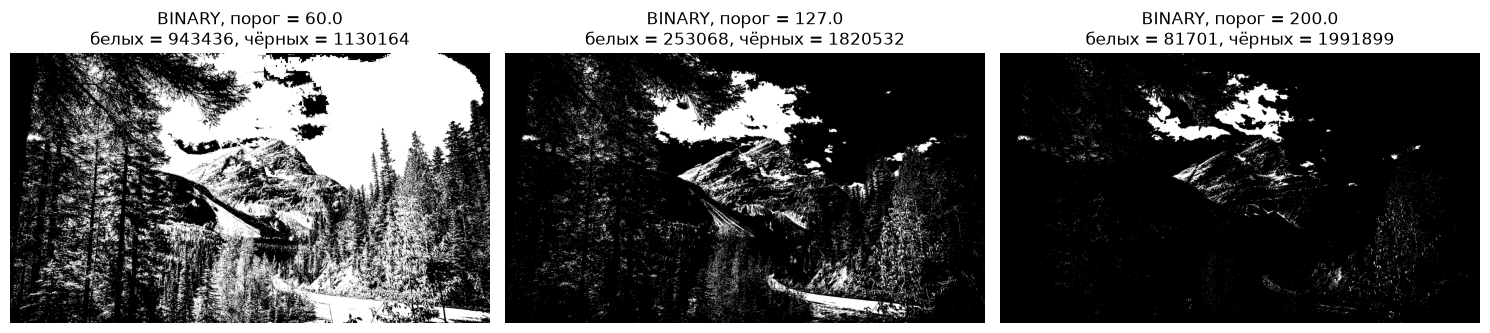

In [58]:
print("BINARY при разных порогах:")
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, t in zip(axes, [60, 127, 200]):
    used, result = cv2.threshold(image_gray, t, 255, cv2.THRESH_BINARY)
    white = int((result == 255).sum())
    black = int((result == 0).sum())
    ax.imshow(result, cmap="gray")
    ax.set_title(f"BINARY, порог = {used}\nбелых = {white}, чёрных = {black}")
    ax.axis("off")
    print(f"   порог = {used:>3} -> белых: {white:>7}, чёрных: {black:>7}")
plt.tight_layout()
plt.show()


TRUNC при разных порогах:
   порог = 60.0 -> ср. яркость = 39.10
   порог = 127.0 -> ср. яркость = 55.33
   порог = 200.0 -> ср. яркость = 60.84


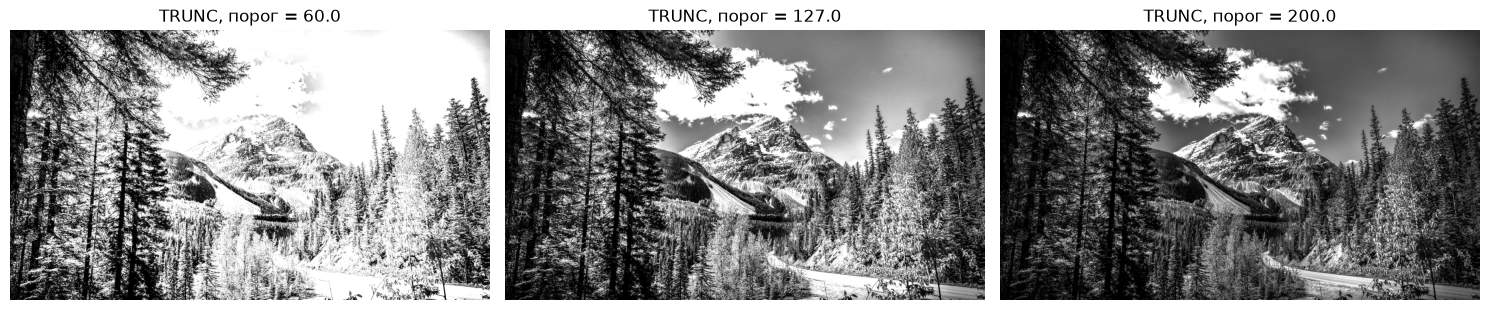

In [59]:
print("\nTRUNC при разных порогах:")
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, t in zip(axes, [60, 127, 200]):
    used, result = cv2.threshold(image_gray, t, 255, cv2.THRESH_TRUNC)
    ax.imshow(result, cmap="gray")
    ax.set_title(f"TRUNC, порог = {used}")
    ax.axis("off")
    print(f"   порог = {used:>3} -> ср. яркость = {result.mean():.2f}")
plt.tight_layout()
plt.show()


TOZERO при разных порогах:
   порог = 60.0 -> ср. яркость = 50.31
   порог = 127.0 -> ср. яркость = 22.28
   порог = 200.0 -> ср. яркость = 9.15


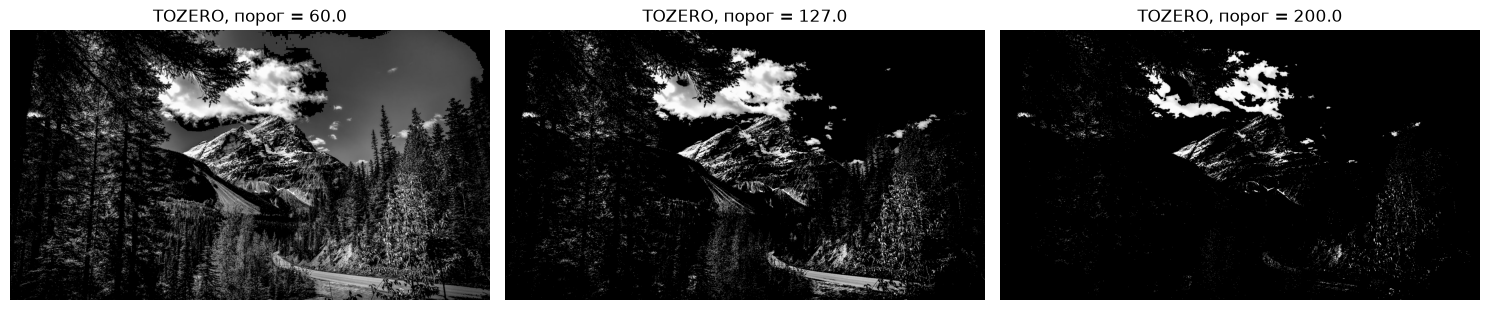

In [60]:
print("\nTOZERO при разных порогах:")
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, t in zip(axes, [60, 127, 200]):
    used, result = cv2.threshold(image_gray, t, 255, cv2.THRESH_TOZERO)
    ax.imshow(result, cmap="gray")
    ax.set_title(f"TOZERO, порог = {used}")
    ax.axis("off")
    print(f"   порог = {used:>3} -> ср. яркость = {result.mean():.2f}")
plt.tight_layout()
plt.show()


Сравнение методов (базовый порог = 127):
   BINARY      -> использованный порог = 127, ср. яркость = 31.12
   BINARY_INV  -> использованный порог = 127, ср. яркость = 223.88
   TRUNC       -> использованный порог = 127, ср. яркость = 55.33
   TOZERO      -> использованный порог = 127, ср. яркость = 22.28
   OTSU        -> использованный порог = 94, ср. яркость = 54.61


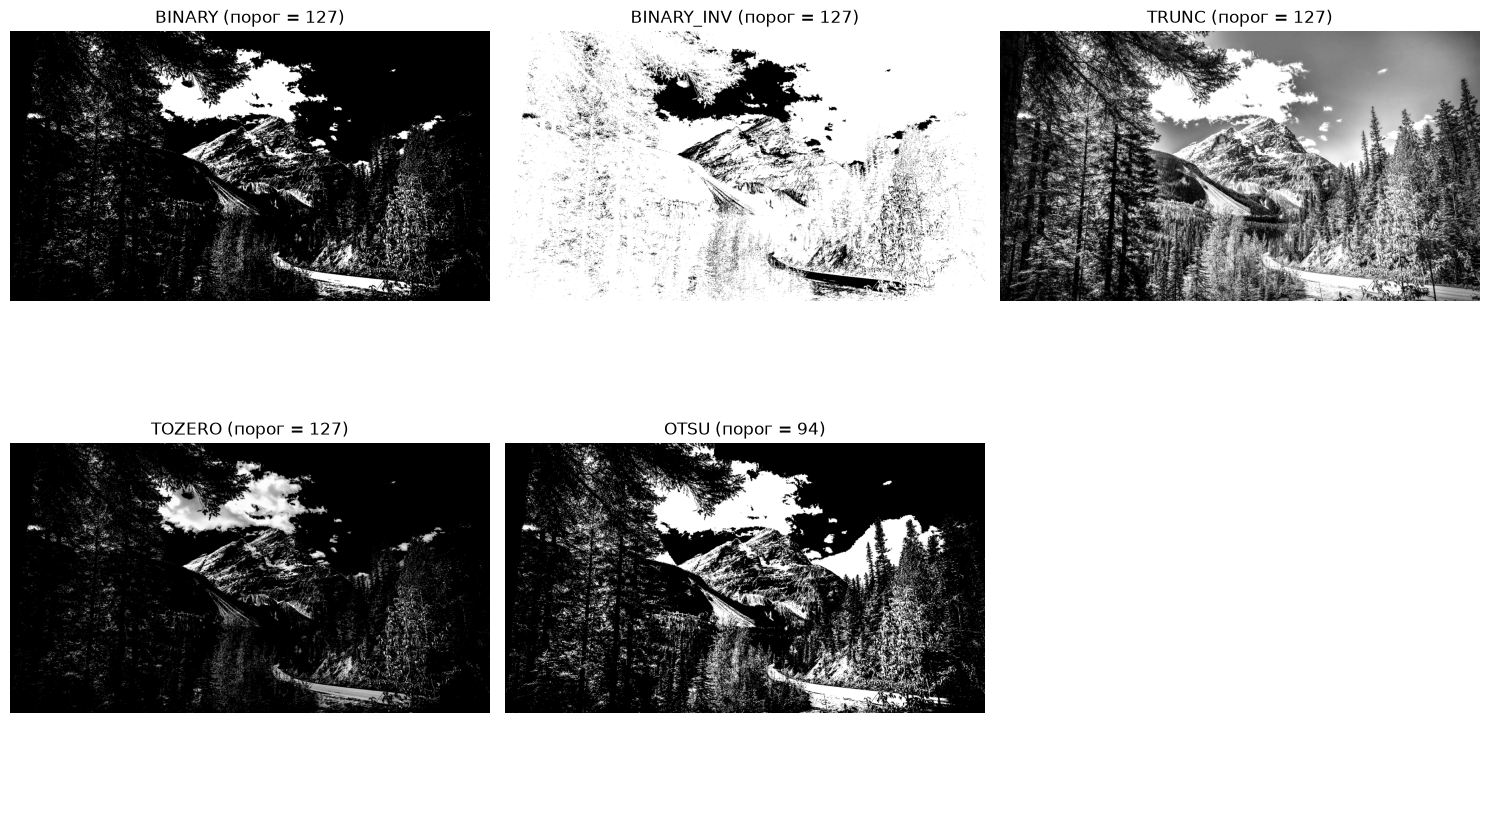

In [61]:
thresh_val = 127
print(f"\nСравнение методов (базовый порог = {thresh_val}):")

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()
for ax, (name, method) in zip(axes, methods.items()):
    used, result = cv2.threshold(image_gray, thresh_val, 255, method)
    ax.imshow(result, cmap="gray")
    ax.set_title(f"{name} (порог = {used:.0f})")
    ax.axis("off")
    print(f"   {name:11s} -> использованный порог = {used:.0f}, ср. яркость = {result.mean():.2f}")

axes[-1].axis("off")
plt.tight_layout()
plt.show()